Chapter 29
# 处理缺失值
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

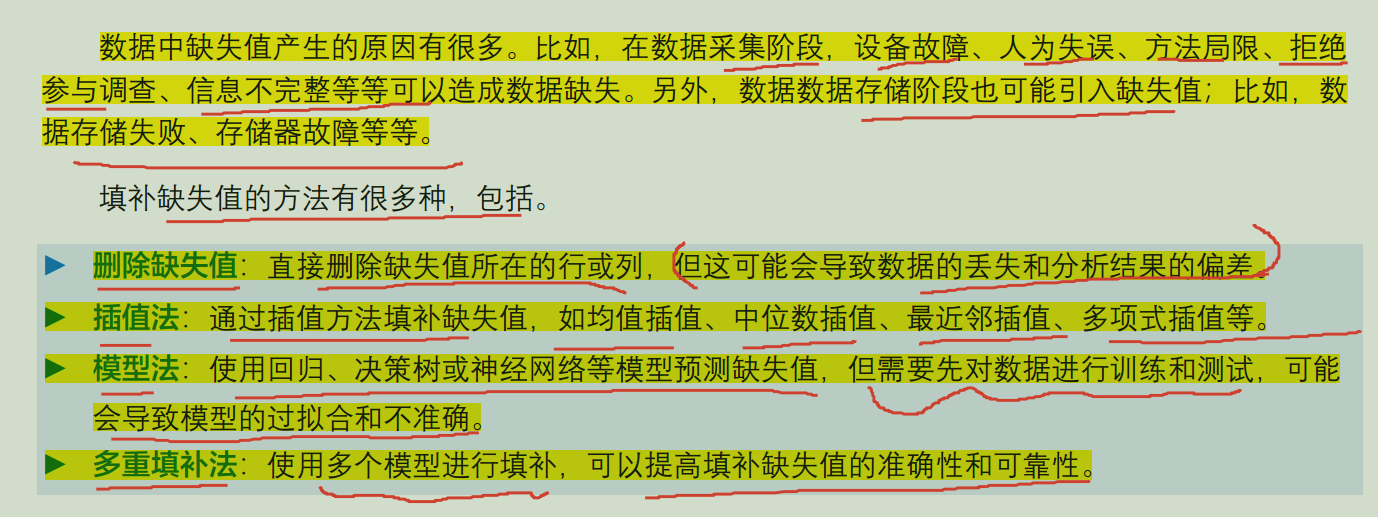

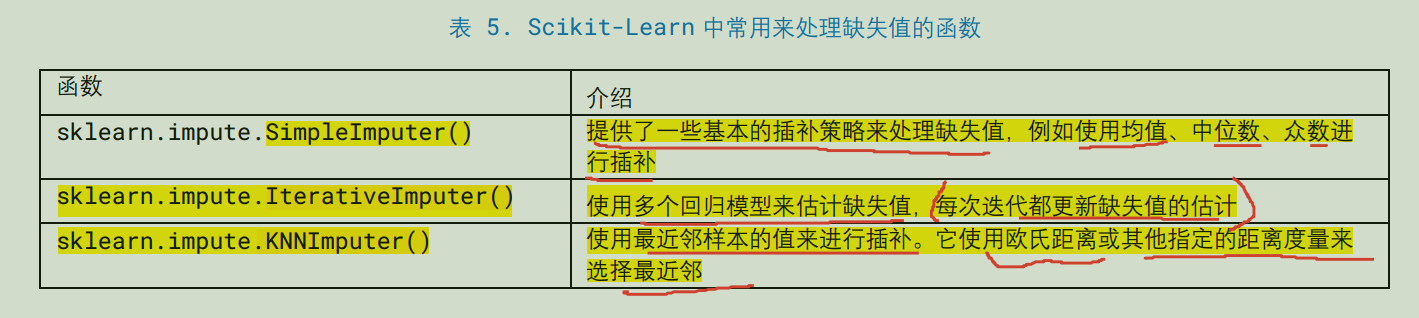

In [1]:
from sklearn.datasets import load_iris
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

从 sklearn.impute 模块导入 KNNImputer() 函数。KNNImputer() 完成 k 近邻插补。k
近邻算法 (k-nearest neighbors algorithm, k-NN, kNN) 是最基本有监督学习 (supervised
learning) 方法之一，kNN 中的 k 指的是“近邻”的数量。

In [2]:
# 导入鸢尾花数据
X, y = load_iris(as_frame=True, return_X_y=True)
# X数据帧； y:series；标签

In [3]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


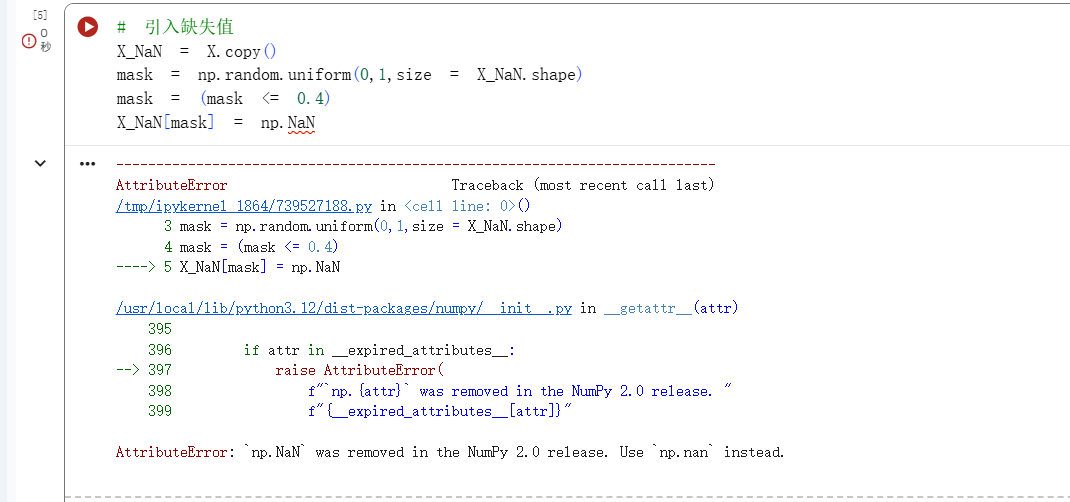

## 引入缺失值

利用 numpy.random.uniform() 产生 [0, 1) 之间连续均匀随机数 NumPy 数组，数组形
状和鸢尾花特征数据形状一致。


将原先生成的随机数数组 mask 中小于等于 0.4 的元素标记为 True，其余元素标记为
False。这样，mask 数组中的元素将形成一个“面具” (布尔掩码)，用来选择哪些位置将被置为缺失
值。

大家也可以使用 numpy.random.choice() 函数来完成上述操作。这个函数用于从给定的一维
数组或类似序列中按指定概率值随机抽取元素。

比如 numpy.random.choice([True, False], p = (0.4, 0.6), size = (150,
4))，列表 [True, False] 为要从中进行抽样的序列源，p 是概率分布数组，用于指定从序列中每
个元素被选中的概率。我们还可以指定是否允许重复抽取，默认允许重复抽取。


将 X_NaN 数组中根据 mask 中对应位置为 True 的元素，设置为缺失值 (NaN)。换句话
说，该代码将 X_NaN 数组中部分元素置为缺失值，而其他元素保持不变。
为了准确获取缺失值位置、数量等信息，对于 Pandas 数据帧数据可以采用 isna() 或 notna()
方法。


In [9]:
# 引入缺失值
X_NaN = X.copy() # 拷贝数据
mask = np.random.uniform(0,1,size = X_NaN.shape)
print(mask)
mask = (mask <= 0.4) # 掩码 <=0.4
print(mask)
# 布尔
print(X_NaN[mask])
X_NaN[mask] = np.nan # 满足条件的行数据赋值为 null

[[1.14505402e-01 7.89479137e-01 1.13345520e-01 3.62069194e-01]
 [6.94014159e-01 7.79658256e-02 6.28768865e-01 5.20480625e-01]
 [4.33716509e-01 4.91994991e-01 2.70967758e-01 1.30966683e-01]
 [9.40249936e-01 1.39059723e-01 4.47559949e-01 1.79360466e-01]
 [4.23636447e-02 6.28391219e-01 6.27662511e-01 9.30305523e-01]
 [5.55393270e-01 5.17894630e-01 9.19605341e-01 1.06985108e-01]
 [6.39550785e-01 6.93950764e-01 5.36148402e-01 9.06912599e-01]
 [7.30474620e-01 3.92795035e-01 6.13362267e-01 5.79072470e-02]
 [5.76003514e-01 2.83856776e-02 2.45221126e-01 9.42695737e-01]
 [4.62539265e-01 5.08443899e-01 9.57722279e-01 5.13957854e-01]
 [3.38450936e-01 6.13508440e-02 6.98277436e-01 3.15252436e-01]
 [7.16835487e-01 7.34338428e-01 2.59881343e-01 1.93516436e-02]
 [7.53556424e-02 2.85459200e-01 8.28403801e-01 2.00954740e-01]
 [7.19870083e-01 3.42035928e-01 5.46019937e-02 3.93095935e-01]
 [9.51054762e-01 7.81207531e-01 6.65731592e-01 1.17512026e-01]
 [1.12578285e-01 5.33474442e-01 1.52234387e-01 3.727137

In [10]:
mask.size

600

In [15]:
X_NaN.loc[:, [True, False, True, False]]  # 查看第0行，指定列

,sepal length (cm),petal length (cm)
0,NaN,NaN
1,4.9,1.4
2,4.7,NaN
3,4.6,1.5
4,NaN,1.4
...,...,...
145,6.7,5.2
146,NaN,5.0
147,NaN,NaN
148,NaN,NaN


In [16]:
X_NaN.iloc[:, [True, False, True, False]]  # 查看第0行，指定列

,sepal length (cm),petal length (cm)
0,NaN,NaN
1,4.9,1.4
2,4.7,NaN
3,4.6,1.5
4,NaN,1.4
...,...,...
145,6.7,5.2
146,NaN,5.0
147,NaN,NaN
148,NaN,NaN


In [8]:
X_NaN

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,NaN,3.5,NaN,NaN
1,4.9,NaN,NaN,0.2
2,4.7,3.2,1.3,NaN
3,4.6,NaN,1.5,0.2
4,NaN,3.6,1.4,0.2
...,...,...,...,...
145,6.7,NaN,5.2,2.3
146,NaN,NaN,5.0,1.9
147,6.5,3.0,5.2,2.0
148,NaN,3.4,5.4,2.3


In [17]:
iris_df_NaN = X_NaN.copy() # 复制数据
iris_df_NaN['species'] = y # 添加标签列

In [18]:
iris_df_NaN

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,NaN,3.5,NaN,NaN,0
1,4.9,NaN,1.4,0.2,0
2,4.7,3.2,NaN,NaN,0
3,4.6,NaN,1.5,NaN,0
4,NaN,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,NaN,NaN,5.0,NaN,2
147,NaN,NaN,NaN,NaN,2
148,NaN,3.4,NaN,2.3,2


# 可视化缺失值位置

采用 iris_df_NaN.isna()，返回具体位置数据是否为缺失值。数据缺失的话，为 True；否
则，为 False。sklearn.impute.MissingIndicator() 也可以用来获取缺失值位置。


In [19]:
iris_df_NaN.isna()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,True,False,True,True,False
1,False,True,False,False,False
2,False,False,True,True,False
3,False,True,False,True,False
4,True,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,True,True,False,True,False
147,True,True,True,True,False
148,True,False,True,False,False


In [21]:
iris_df_NaN.isnull()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,True,False,True,True,False
1,False,True,False,False,False
2,False,False,True,True,False
3,False,True,False,True,False
4,True,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,True,True,False,True,False
147,True,True,True,True,False
148,True,False,True,False,False


In [20]:
iris_df_NaN.isnull().sum() # 统计每一列为空的个数；每个特征

,0
sepal length (cm),57
sepal width (cm),60
petal length (cm),62
petal width (cm),62
species,0


In [22]:
# 可视化缺失值位置
is_NaN = iris_df_NaN.isna() # 将nan位置转为true；好方便sum进行统计个数
print(iris_df_NaN.isnull().sum() * 100 / len(iris_df_NaN)) # 统计每一列为空的个数；每个特征

sepal length (cm)    38.000000
sepal width (cm)     40.000000
petal length (cm)    41.333333
petal width (cm)     41.333333
species               0.000000
dtype: float64


##为采用 seaborn.heatmap() 可视化数据缺失值，图 5 所示热图的每一条黑色条带代表一个缺
失值。使用缺失值热图可以粗略观察得到缺失值分布情况。


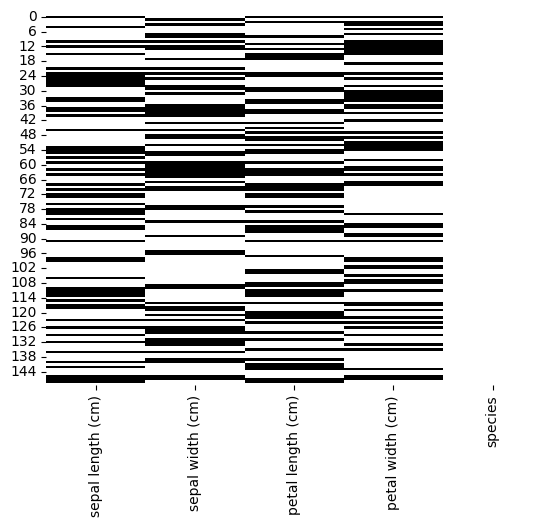

In [23]:
fig, ax = plt.subplots()
# is_NaN为位置为 nan 转为 true
ax = sns.heatmap(is_NaN,
                 cmap='gray_r',
                 cbar=False)

 # 用kNN插补

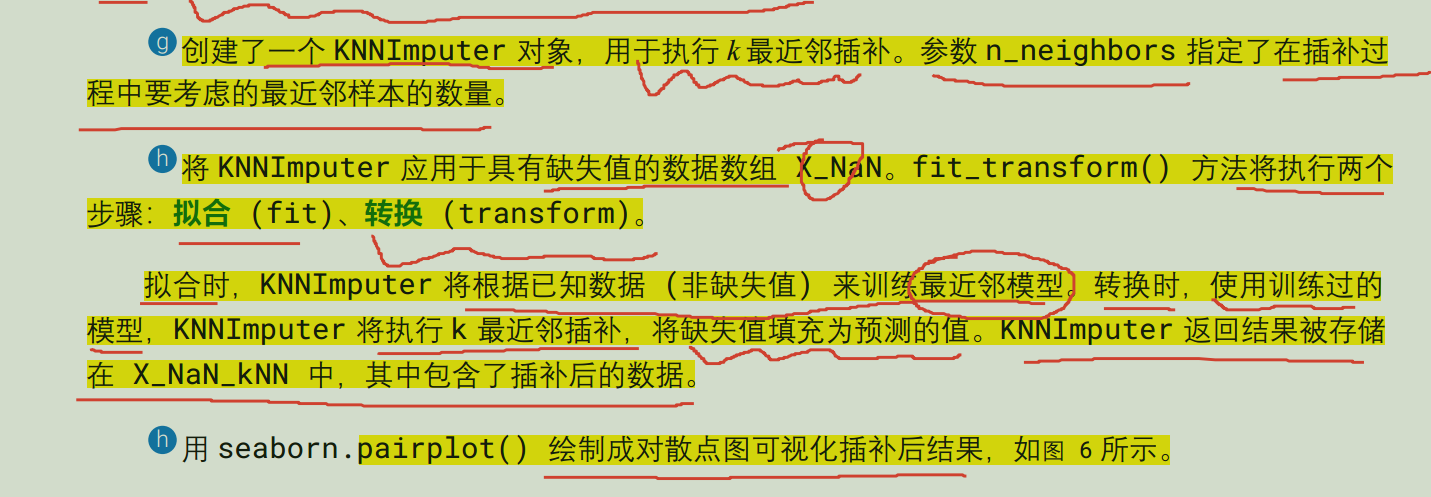

In [24]:
               # 用kNN插补
knni = KNNImputer(n_neighbors=5)  # 创建一个KNNImputer对象；用于执行 k 最近邻插补。参数 n_neighbors 指定了在插补过
                    #程中要考虑的最近邻样本的数量。
# 将 KNNImputer 应用于具有缺失值的数据数组 X_NaN。fit_transform() 方法将执行两个
# 步骤：拟合 (fit)、转换 (transform)。
X_NaN_kNN = knni.fit_transform(X_NaN)
# 为拟合转换后的数据 创建一个数据帧；行列名不变
iris_df_kNN = pd.DataFrame(X_NaN_kNN, columns=X_NaN.columns,
                           index=X_NaN.index)
iris_df_kNN['species'] = y # 添加种类标签

In [26]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [25]:
iris_df_kNN # 为缺失值的位置添加数据

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.140000,3.500000,1.440000,0.6600,0
1,4.900000,3.580000,1.400000,0.2000,0
2,4.700000,3.200000,2.260000,0.8800,0
3,4.600000,3.420000,1.500000,0.3000,0
4,4.880000,3.600000,1.400000,0.2000,0
...,...,...,...,...,...
145,6.700000,3.000000,5.200000,2.3000,2
146,6.020000,2.860000,5.000000,1.9600,2
147,5.870968,3.056667,3.670455,1.3125,2
148,6.280000,3.400000,5.800000,2.3000,2


## seaborn.pairplot() 绘制成对散点图可视化插补后结果，

3. hue='species'
作用：按照 'species' 列的值对数据点进行颜色分类效果：

不同品种（setosa、versicolor、virginica）用不同颜色表示

便于观察不同类别在特征空间中的分布和分离情况

图例：自动生成颜色对应的品种名称

4. palette="bright"
作用：设置颜色配色方案

"bright"：使用明亮、饱和度高的颜色组合

其他常用选项：

"deep"（默认）：深色系

"muted"：柔和色系

"dark"：暗色系

"colorblind"：色盲友好

"Set1", "Set2", "Set3"：分类调色板

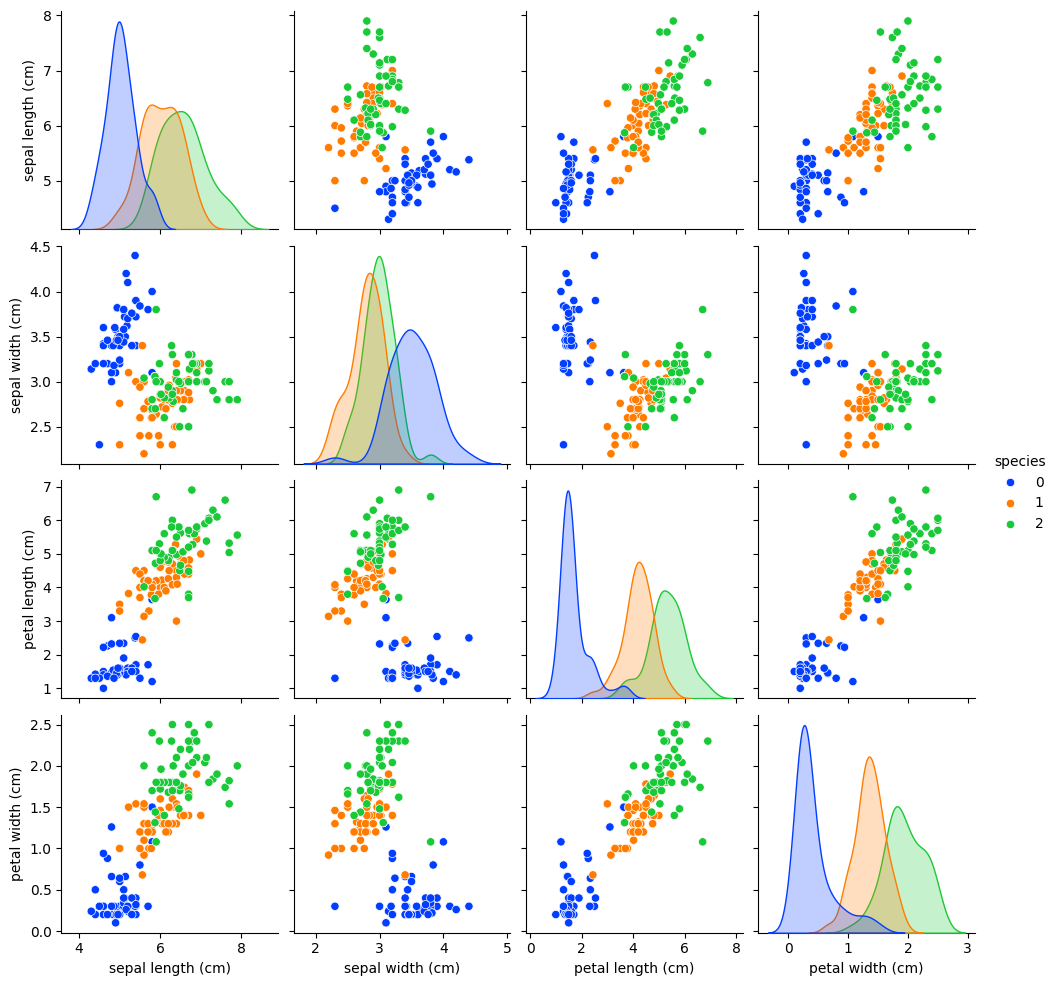

In [27]:
sns.pairplot(iris_df_kNN, hue='species',
             palette = "bright")

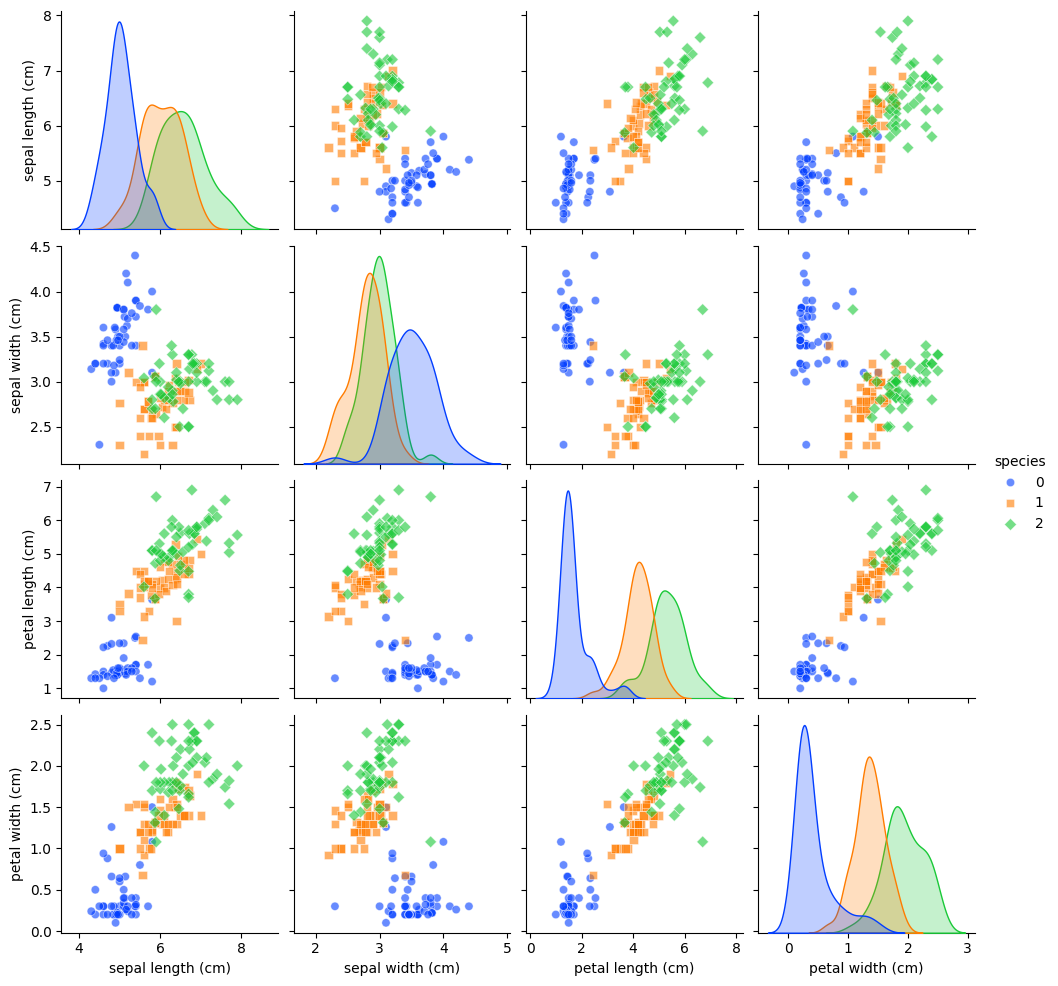

In [28]:
sns.pairplot(iris_df_kNN,
             hue='species',           # 颜色分类
             palette="bright",        # 配色方案
             diag_kind='kde',         # 对角线用核密度图（默认'hist'）
             markers=['o', 's', 'D'], # 不同类别的标记形状
             height=2.5,              # 每个子图的大小
             plot_kws={'alpha':0.6})  # 散点图透明度